# Studying the most efficient implementation of X on sharded array

In [1]:
import os
import logging
import numpy as np
import h5py
import jax
import jax.numpy as jnp
from jax.sharding import PartitionSpec, AxisType, NamedSharding
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.ground_locg import ground_locg

os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.1'
jax.config.update('jax_enable_x64', True)
logging.basicConfig(level=logging.INFO)

In [2]:
mesh = jax.make_mesh((2, 2, 2), ('X', 'Y', 'Z'), (AxisType.Explicit,) * 3)
jax.set_mesh(mesh)

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [4]:
arr = jax.device_put(jnp.arange(128).reshape((2,) * 7), device=PartitionSpec('X', 'Y', 'Z'))

In [7]:
jnp.moveaxis(arr, 0, -1).addressable_shards

[Shard(device=CudaDevice(id=0), index=(slice(0, 1, None), slice(0, 1, None), slice(None, None, None), slice(None, None, None), slice(None, None, None), slice(None, None, None), slice(0, 1, None)), replica_id=0, data=[[[[[[[ 0]
       [ 1]]
 
      [[ 2]
       [ 3]]]
 
 
     [[[ 4]
       [ 5]]
 
      [[ 6]
       [ 7]]]]
 
 
 
    [[[[ 8]
       [ 9]]
 
      [[10]
       [11]]]
 
 
     [[[12]
       [13]]
 
      [[14]
       [15]]]]]]]),
 Shard(device=CudaDevice(id=1), index=(slice(0, 1, None), slice(1, 2, None), slice(None, None, None), slice(None, None, None), slice(None, None, None), slice(None, None, None), slice(0, 1, None)), replica_id=0, data=[[[[[[[16]
       [17]]
 
      [[18]
       [19]]]
 
 
     [[[20]
       [21]]
 
      [[22]
       [23]]]]
 
 
 
    [[[[24]
       [25]]
 
      [[26]
       [27]]]
 
 
     [[[28]
       [29]]
 
      [[30]
       [31]]]]]]]),
 Shard(device=CudaDevice(id=2), index=(slice(1, 2, None), slice(0, 1, None), slice(None, None, None), sl

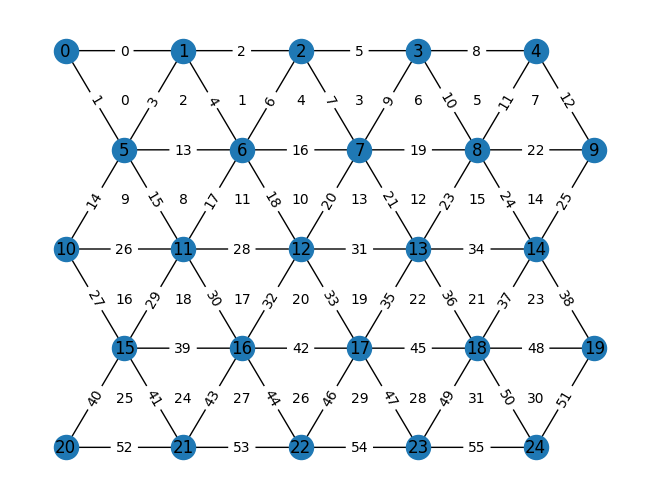

In [2]:
lattice = TriangularZ2Lattice((4, 8))
lattice.draw_graph();

In [ ]:
base_link_state = np.zeros(lattice.num_links, dtype=np.uint8)
# base_link_state[::-1][[26, 28, 31, 34]] = 1
# base_link_state[::-1][[10, 13, 16]] = 1
base_link_state[::-1][[20, 22, 25]] = 1
dual_lattice = lattice.plaquette_dual(base_link_state)
nplaq = lattice.num_plaquettes
hamiltonian = dual_lattice.make_hamiltonian(0.8)
# vinit = jax.nn.one_hot(0, 2 ** nplaq)
# vinit = jax.device_put(vinit, PartitionSpec('X'))

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


## With moveaxis

In [ ]:
def make_apply_z(axis):
    def apply_z(result, vec, coeff):
        val = jnp.moveaxis(vec, axis, -1)
        val *= jnp.array([coeff, -coeff])
        val = jnp.moveaxis(val, -1, axis)
        result += val
        return result

    return apply_z

In [ ]:
def make_apply_zz(axis1, axis2):
    def apply_zz(result, vec, coeff):
        val = jnp.moveaxis(vec, (axis1, axis2), (-2, -1))
        val *= jnp.array([[coeff, -coeff], [-coeff, coeff]])
        val = jnp.moveaxis(val, (-2, -1), (axis1, axis2))
        result += val
        return result

    return apply_zz

In [ ]:
def make_apply_x(axis):
    def apply_x(result, vec):
        result += jnp.flip(vec, axis=axis)
        return result

    return apply_x

In [ ]:
def make_apply_h(hamiltonian):
    z_coeffs = {}
    zz_coeffs = {}
    x_coeff = 0.

    for pauli, coeff in zip(hamiltonian.paulis, hamiltonian.coeffs.real):
        zs = np.nonzero(pauli.z[::-1])[0].astype(np.int64)
        xs = np.nonzero(pauli.x[::-1])[0].astype(np.int64)
        if zs.shape[0] == 1:
            if zs[0] in z_coeffs:
                z_coeffs[zs[0]] += coeff
            else:
                z_coeffs[zs[0]] = coeff
        elif zs.shape[0] == 2:
            key = (zs[0], zs[1])
            if key in zz_coeffs:
                zz_coeffs[key] += coeff
            else:
                zz_coeffs[key] = coeff
        else:
            x_coeff = coeff

    nq = hamiltonian.num_qubits
    z_fns = [make_apply_z(nq, ax) for ax in z_coeffs.keys()]
    z_coeffs = jnp.array(list(z_coeffs.values()))
    zz_fns = [make_apply_zz(nq, *axs) for axs in zz_coeffs.keys()]
    zz_coeffs = jnp.array(list(zz_coeffs.values()))
    x_fns = [make_apply_x(ax) for ax in range(nq)]

    def z_body(iop, val):
        result, vec, coeffs = val
        result = jax.lax.switch(iop, z_fns, result, vec, coeffs[iop])
        return (result, vec, coeffs)

    def zz_body(iop, val):
        result, vec, coeffs = val
        result = jax.lax.switch(iop, zz_fns, result, vec, coeffs[iop])
        return (result, vec, coeffs)

    def x_body(iop, val):
        result, vec = val
        result = jax.lax.switch(iop, x_fns, result, vec)
        return (result, vec)


    @jax.jit
    def apply_h(vec):
        vec = vec.reshape((2,) * nplaq)
        result = jnp.zeros_like(vec)
        result = jax.lax.fori_loop(0, nq, x_body, (result, vec))[0]
        result *= x_coeff
        result = jax.lax.fori_loop(0, z_coeffs.shape[0], z_body, (result, vec, z_coeffs))[0]
        result = jax.lax.fori_loop(0, zz_coeffs.shape[0], zz_body, (result, vec, zz_coeffs))[0]

        return result.reshape(-1)

    return apply_h

In [ ]:
apply_h = make_apply_h(hamiltonian)

In [ ]:
apply_h(vinit)

In [ ]:
ground_locg(apply_h, vinit)

In [ ]:
with jax.profiler.trace('/tmp/ground_4x8'):
    ground_locg(apply_h, vinit)

## With expand_dims

In [5]:
def make_apply_z(nq, axis):
    def apply_z(result, vec, coeff):
        axes = list(range(nq))
        axes.remove(axis)
        result += jnp.expand_dims(jnp.array([coeff, -coeff]), tuple(axes)) * vec
        return result

    return apply_z

In [6]:
def make_apply_zz(nq, axis1, axis2):
    def apply_zz(result, vec, coeff):
        axes = list(range(nq))
        axes.remove(axis1)
        axes.remove(axis2)
        result += jnp.expand_dims(jnp.array([[coeff, -coeff], [-coeff, coeff]]), tuple(axes)) * vec
        return result

    return apply_zz

In [7]:
def make_apply_x(axis):
    def apply_x(result, vec):
        result += jnp.flip(vec, axis=axis)
        return result

    return apply_x

In [8]:
def make_apply_h(hamiltonian):
    z_coeffs = {}
    zz_coeffs = {}
    x_coeff = 0.

    for pauli, coeff in zip(hamiltonian.paulis, hamiltonian.coeffs.real):
        zs = np.nonzero(pauli.z[::-1])[0].astype(np.int64)
        xs = np.nonzero(pauli.x[::-1])[0].astype(np.int64)
        if zs.shape[0] == 1:
            if zs[0] in z_coeffs:
                z_coeffs[zs[0]] += coeff
            else:
                z_coeffs[zs[0]] = coeff
        elif zs.shape[0] == 2:
            key = (zs[0], zs[1])
            if key in zz_coeffs:
                zz_coeffs[key] += coeff
            else:
                zz_coeffs[key] = coeff
        else:
            x_coeff = coeff

    nq = hamiltonian.num_qubits
    z_fns = [make_apply_z(nq, ax) for ax in z_coeffs.keys()]
    z_coeffs = jnp.array(list(z_coeffs.values()))
    zz_fns = [make_apply_zz(nq, *axs) for axs in zz_coeffs.keys()]
    zz_coeffs = jnp.array(list(zz_coeffs.values()))
    x_fns = [make_apply_x(ax) for ax in range(nq)]

    def z_body(iop, val):
        result, vec, coeffs = val
        result = jax.lax.switch(iop, z_fns, result, vec, coeffs[iop])
        return (result, vec, coeffs)

    def zz_body(iop, val):
        result, vec, coeffs = val
        result = jax.lax.switch(iop, zz_fns, result, vec, coeffs[iop])
        return (result, vec, coeffs)

    def x_body(iop, val):
        result, vec = val
        result = jax.lax.switch(iop, x_fns, result, vec)
        return (result, vec)


    @jax.jit
    def apply_h(vec):
        vec = vec.reshape((2,) * nplaq)
        result = jnp.zeros_like(vec)
        result = jax.lax.fori_loop(0, nq, x_body, (result, vec))[0]
        result *= x_coeff
        result = jax.lax.fori_loop(0, z_coeffs.shape[0], z_body, (result, vec, z_coeffs))[0]
        result = jax.lax.fori_loop(0, zz_coeffs.shape[0], zz_body, (result, vec, zz_coeffs))[0]

        return result.reshape(-1)

    return apply_h

In [9]:
apply_h = make_apply_h(hamiltonian)

In [10]:
jax.make_jaxpr(apply_h)(vinit)

{ lambda ; a:f64[16777216]. let
    b:f64[16777216] = jit[
      name=apply_h
      jaxpr={ lambda c:f64[12] d:f64[29]; a:f64[16777216]. let
          e:f64[2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2] = reshape[
            dimensions=None
            new_sizes=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)
            sharding=None
          ] a
          f:f64[2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2] = broadcast_in_dim 0.0:f64[]
          _:i64[] g:f64[2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2] = scan[
            _split_transpose=False
            jaxpr={ lambda ; h:f64[2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2]
                i:i64[] j:f64[2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2]. let
                k:i64[] = add i 1:i64[]
                l:i32[] = convert_element_type[new_dtype=int32 weak_type=False] i
                m:i32[] = clamp 0:i32[] l 23:i32[]
                n:f64[2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2

In [ ]:
apply_h(vinit)

In [ ]:
ground_locg(apply_h, vinit)

In [ ]:
with jax.profiler.trace('/tmp/ground_4x8'):
    ground_locg(apply_h, vinit)

## With indexing

In [ ]:
def apply_z(iop, val):
    result, vec, iqs, signs = val
    iq = iqs[iop]
    positive = signs[iop]
    indices = jnp.nonzero((jnp.arange(vec.shape[0], dtype=np.uint64) >> iq) & 1, size=vec.shape[0] // 2)
    result = jax.lax.cond(
        positive,
        lambda r, v, i: r.at[i].subtract(v[i]),
        lambda r, v, i: r.at[i].add(v[i]),
        result, vec, indices
    )
    indices = jnp.nonzero((jnp.arange(vec.shape[0], dtype=np.uint64) >> iq) & 1 == 0, size=vec.shape[0] // 2)
    result = jax.lax.cond(
        positive,
        lambda r, v, i: r.at[i].add(v[i]),
        lambda r, v, i: r.at[i].subtract(v[i]),
        result, vec, indices
    )
    return (result, vec, iqs, signs)

In [ ]:
def apply_zz(iop, val):
    result, vec, iq1s, iq2s, signs = val
    iq1 = iq1s[iop]
    iq2 = iq2s[iop]
    mask = (1 << iq1) | (1 << iq2)
    positive = signs[iop]
    indices = jnp.nonzero(jnp.bitwise_count(jnp.arange(vec.shape[0], dtype=np.uint64) & mask) % 2 == 1, size=vec.shape[0] // 2)
    result = jax.lax.cond(
        positive,
        lambda r, v, i: r.at[i].subtract(v[i]),
        lambda r, v, i: r.at[i].add(v[i]),
        result, vec, indices
    )
    indices = jnp.nonzero(jnp.bitwise_count(jnp.arange(vec.shape[0], dtype=np.uint64) & mask) % 2 == 0, size=vec.shape[0] // 2)
    result = jax.lax.cond(
        positive,
        lambda r, v, i: r.at[i].add(v[i]),
        lambda r, v, i: r.at[i].subtract(v[i]),
        result, vec, indices
    )
    return (result, vec, iq1s, iq2s, signs)

In [ ]:
def make_apply_h(hamiltonian):
    z_iqs = []
    z_signs = []
    zz_iq1s = []
    zz_iq2s = []
    zz_signs = []

    nq = hamiltonian.num_qubits

    for pauli, coeff in zip(hamiltonian.paulis, hamiltonian.coeffs.real):
        zs = np.nonzero(pauli.z[::-1])[0].astype(np.int64)
        xs = np.nonzero(pauli.x[::-1])[0].astype(np.int64)
        if zs.shape[0] == 1:
            z_iqs.append(nq - zs[0] - 1)
            z_signs.append(coeff > 0.)
        elif zs.shape[0] == 2:
            zz_iq1s.append(nq - zs[0] - 1)
            zz_iq2s.append(nq - zs[1] - 1)
            zz_signs.append(coeff > 0.)

    z_iqs = jnp.array(z_iqs, dtype=np.uint8)
    z_signs = jnp.array(z_signs)
    zz_iq1s = jnp.array(zz_iq1s, dtype=np.uint8)
    zz_iq2s = jnp.array(zz_iq2s, dtype=np.uint8)
    zz_signs = jnp.array(zz_signs)

    @jax.jit
    def apply_h(vec):
        result = jnp.zeros_like(vec)
        val = (result, vec, z_iqs, z_signs)
        result = jax.lax.fori_loop(0, z_signs.shape[0], apply_z, val)[0]
        val = (result, vec, zz_iq1s, zz_iq2s, zz_signs)
        result = jax.lax.fori_loop(0, zz_signs.shape[0], apply_zz, val)[0]
        return result

    return apply_h


In [ ]:
apply_h = make_apply_h(hamiltonian)

In [ ]:
apply_h(vinit)

In [ ]:
ground_locg(apply_h, vinit)

In [ ]:
with jax.profiler.trace('/tmp/ground_4x8'):
    ground_locg(apply_h, vinit)

## With slicing

In [5]:
def make_apply_z(axis, coeff):
    def apply_z(result, vec):
        slices_left = (slice(None),) * axis
        if coeff < 0.:
            indices = [0, 1]
        else:
            indices = [1, 0]
        index = slices_left + (indices[0],)
        result = result.at[index].subtract(vec[index])
        index = slices_left + (indices[1],)
        result = result.at[index].add(vec[index])
        return result

    return apply_z

In [6]:
def make_apply_zz(axis1, axis2, coeff):
    def apply_zz(result, vec):
        slices_left = (slice(None),) * axis1
        slices_right = (slice(None),) * (axis2 - axis1 - 1)
        if coeff < 0.:
            indices = [(0, 0), (0, 1), (1, 0), (1, 1)]
        else:
            indices = [(0, 1), (0, 0), (1, 1), (1, 0)]
        index = slices_left + indices[0][:1] + slices_right + indices[0][1:]
        result = result.at[index].subtract(vec[index])
        index = slices_left + indices[1][:1] + slices_right + indices[1][1:]
        result = result.at[index].add(vec[index])
        index = slices_left + indices[2][:1] + slices_right + indices[2][1:]
        result = result.at[index].add(vec[index])
        index = slices_left + indices[3][:1] + slices_right + indices[3][1:]
        result = result.at[index].subtract(vec[index])
        return result

    return apply_zz

In [7]:
def make_apply_x(axis):
    def apply_x(result, lambda_vec):
        slices_left = (slice(None),) * axis
        index_out = slices_left + (slice(None, None, -1),)
        result = result.at[index_out].subtract(lambda_vec)
        return result

    return apply_x

In [8]:
def make_apply_h(hamiltonian):
    diag_fns = []
    x_fns = []
    x_coeff = 0.

    for pauli, coeff in zip(hamiltonian.paulis, hamiltonian.coeffs.real):
        zs = np.nonzero(pauli.z[::-1])[0].astype(np.int64)
        xs = np.nonzero(pauli.x[::-1])[0].astype(np.int64)
        if zs.shape[0] == 1:
            diag_fns.append(make_apply_z(zs[0], coeff.real))
        elif zs.shape[0] == 2:
            diag_fns.append(make_apply_zz(zs[0], zs[1], coeff.real))
        else:
            x_coeff = coeff.real
            x_fns.append(make_apply_x(xs[0]))

    def body_diag(iop, val):
        result, vec = val
        result = jax.lax.switch(iop, diag_fns, result, vec)
        return (result, vec)

    def body_x(iop, val):
        result, lambda_vec = val
        result = jax.lax.switch(iop, x_fns, result, lambda_vec)
        return (result, lambda_vec)

    @jax.jit
    def apply_h(vec):
        vec = vec.reshape((2,) * nplaq)
        result = jnp.zeros_like(vec)
        result = jax.lax.fori_loop(0, len(diag_fns), body_diag, (result, vec))[0]
        lambda_vec = x_coeff * vec
        result = jax.lax.fori_loop(0, len(x_fns), body_x, (result, lambda_vec))[0]
        return result.reshape(-1)

    return apply_h

In [9]:
apply_h = make_apply_h(hamiltonian)

In [10]:
jax.make_jaxpr(apply_h)(vinit)

let jaxpr = { lambda ; a:f64[] b:f64[]. let c:f64[] = sub a b in (c,) } in
let jaxpr1 = { lambda ; d:f64[] e:f64[]. let f:f64[] = add d e in (f,) } in
{ lambda ; g:f64[16777216]. let
    h:f64[16777216] = jit[
      name=apply_h
      jaxpr={ lambda ; g:f64[16777216]. let
          i:f64[2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2] = reshape[
            dimensions=None
            new_sizes=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)
            sharding=None
          ] g
          j:f64[2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2] = broadcast_in_dim 0.0:f64[]
          _:i64[] k:f64[2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2] = scan[
            _split_transpose=False
            jaxpr={ lambda ; l:f64[2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2]
                m:i64[] n:f64[2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2]. let
                o:i64[] = add m 1:i64[]
                p:i32[] = convert_element_type[new_dtype=int32 weak_ty

In [ ]:
apply_h(vinit)

In [ ]:
ground_locg(apply_h, vinit)

In [ ]:
with jax.profiler.trace('/tmp/ground_4x8'):
    ground_locg(apply_h, vinit)

In [ ]:
with jax.profiler.trace('/tmp/ground_4x8'):
    ground_locg(apply_h_arithmetic, vinit)